In [15]:
# Jupyter cell: read two ROS 2 bags and compare /limo_1/pmp_vel

from collections import defaultdict
from pathlib import Path

import rosbag2_py
import pandas as pd
import matplotlib.pyplot as plt
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message


# ============================================================
# User settings
# ============================================================
bag_paths = {
    "optimal": str(Path("~/code/limo_dev_ws/src/limo_cruise_control_py/bags/optimal2").expanduser()),
    "modelbased": str(Path("~/code/limo_dev_ws/src/limo_cruise_control_py/bags/modelbased2").expanduser()),
}
storage_id = "sqlite3"   # change to "mcap" if needed


# ============================================================
# Topics we want to read
# ============================================================
target_topics = {
    "/limo_1/cmd_vel": "geometry_msgs/msg/Twist",
    "/limo_2/cmd_vel": "geometry_msgs/msg/Twist",
    "/limo_1/odometry/filtered": "nav_msgs/msg/Odometry",
    "/limo_2/odometry/filtered": "nav_msgs/msg/Odometry",
    "/limo_1/pmp_vel": "geometry_msgs/msg/Twist",
}


# ============================================================
# Helper function to read one bag
# ============================================================
def read_bag_to_dfs(bag_path, storage_id, target_topics):
    reader = rosbag2_py.SequentialReader()
    reader.open(
        rosbag2_py.StorageOptions(uri=bag_path, storage_id=storage_id),
        rosbag2_py.ConverterOptions(
            input_serialization_format="cdr",
            output_serialization_format="cdr"
        )
    )

    # Read topic/type metadata
    all_topics_and_types = reader.get_all_topics_and_types()
    bag_topic_types = {item.name: item.type for item in all_topics_and_types}

    #print(f"\n============================================================")
    #print(f"Reading bag: {bag_path}")
    #print("Topics found in bag:")
    for name, dtype in bag_topic_types.items():
        #print(f"  {name}: {dtype}")
        pass

    # Validate required topics
    missing_topics = [topic for topic in target_topics if topic not in bag_topic_types]
    if missing_topics:
        raise RuntimeError(
            f"In bag {bag_path}, the following required topics were not found:\n"
            + "\n".join(f"  {topic}" for topic in missing_topics)
        )

    wrong_types = []
    for topic_name, expected_type in target_topics.items():
        actual_type = bag_topic_types[topic_name]
        if actual_type != expected_type:
            wrong_types.append((topic_name, expected_type, actual_type))

    if wrong_types:
        msg = f"In bag {bag_path}, the following topics have unexpected datatypes:\n"
        for topic_name, expected_type, actual_type in wrong_types:
            msg += (
                f"  {topic_name}\n"
                f"    expected: {expected_type}\n"
                f"    actual:   {actual_type}\n"
            )
        raise RuntimeError(msg)

    print("All required topics found with correct datatypes.")

    # Precompute ROS message classes
    msg_classes = {
        topic_name: get_message(msg_type)
        for topic_name, msg_type in target_topics.items()
    }

    # Read and parse messages
    data = defaultdict(list)

    while reader.has_next():
        topic_name, serialized_data, t_ns = reader.read_next()

        if topic_name not in target_topics:
            continue

        msg = deserialize_message(serialized_data, msg_classes[topic_name])

        if target_topics[topic_name] == "geometry_msgs/msg/Twist":
            parsed_msg = {
                "time_ns": t_ns,
                "linear_x": msg.linear.x,
                "linear_y": msg.linear.y,
                "linear_z": msg.linear.z,
                "angular_x": msg.angular.x,
                "angular_y": msg.angular.y,
                "angular_z": msg.angular.z,
            }

        elif target_topics[topic_name] == "nav_msgs/msg/Odometry":
            parsed_msg = {
                "time_ns": t_ns,
                "header_stamp_sec": msg.header.stamp.sec,
                "header_stamp_nanosec": msg.header.stamp.nanosec,
                "frame_id": msg.header.frame_id,
                "child_frame_id": msg.child_frame_id,
                "position_x": msg.pose.pose.position.x,
                "position_y": msg.pose.pose.position.y,
                "position_z": msg.pose.pose.position.z,
                "orientation_x": msg.pose.pose.orientation.x,
                "orientation_y": msg.pose.pose.orientation.y,
                "orientation_z": msg.pose.pose.orientation.z,
                "orientation_w": msg.pose.pose.orientation.w,
                "linear_x": msg.twist.twist.linear.x,
                "linear_y": msg.twist.twist.linear.y,
                "linear_z": msg.twist.twist.linear.z,
                "angular_x": msg.twist.twist.angular.x,
                "angular_y": msg.twist.twist.angular.y,
                "angular_z": msg.twist.twist.angular.z,
            }

        data[topic_name].append(parsed_msg)

    # Print summary
    #print("\nMessage counts:")
    for topic_name in target_topics:
        #print(f"  {topic_name}: {len(data[topic_name])} messages")
        pass

    # Convert to pandas DataFrames
    dfs = {
        topic_name: pd.DataFrame(messages)
        for topic_name, messages in data.items()
    }

    return dfs


# ============================================================
# Read both bags
# ============================================================
dfs_optimal = read_bag_to_dfs(bag_paths["optimal"], storage_id, target_topics)
dfs_modelbased = read_bag_to_dfs(bag_paths["modelbased"], storage_id, target_topics)


# ============================================================
# Extract desired dataframes from both bags
# ============================================================
df_pmp_vel_1_optimal = dfs_optimal["/limo_1/pmp_vel"]
df_pmp_vel_1_modelbased = dfs_modelbased["/limo_1/pmp_vel"]

df_odom_1_optimal = dfs_optimal["/limo_1/odometry/filtered"]
df_odom_2_optimal = dfs_optimal["/limo_2/odometry/filtered"]

df_odom_1_mb = dfs_modelbased["/limo_1/odometry/filtered"]
df_odom_2_mb = dfs_modelbased["/limo_2/odometry/filtered"]


[INFO] [1773184062.898106648] [rosbag2_storage]: Opened database '/home/panos/code/limo_dev_ws/src/limo_cruise_control_py/bags/optimal2/rosbag2_2026_03_10-19_03_35_0.db3' for READ_ONLY.
[INFO] [1773184063.046483957] [rosbag2_storage]: Opened database '/home/panos/code/limo_dev_ws/src/limo_cruise_control_py/bags/modelbased2/rosbag2_2026_03_10-19_07_02_0.db3' for READ_ONLY.


All required topics found with correct datatypes.
All required topics found with correct datatypes.


# Raw Data

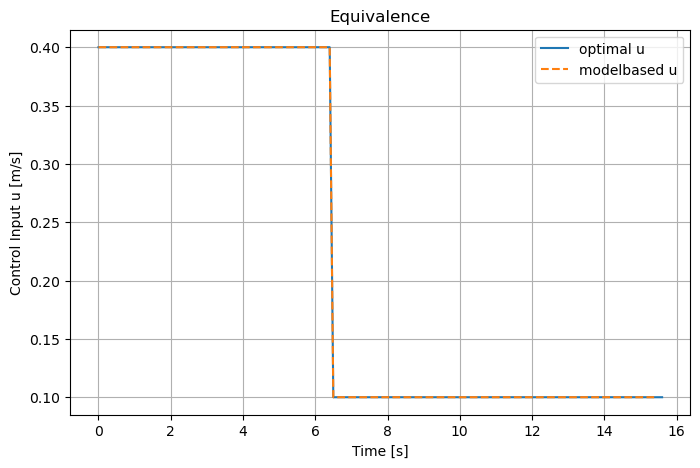

In [16]:
# ============================================================
# Plot control input from both bags on the same plot
# ============================================================
t_opt = (
    (df_pmp_vel_1_optimal["time_ns"] - df_pmp_vel_1_optimal["time_ns"].iloc[0]) * 1e-9
).to_numpy()

t_mb = (
    (df_pmp_vel_1_modelbased["time_ns"] - df_pmp_vel_1_modelbased["time_ns"].iloc[0]) * 1e-9
).to_numpy()

u_opt = df_pmp_vel_1_optimal["linear_x"].to_numpy()
u_mb = df_pmp_vel_1_modelbased["linear_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_opt, u_opt, label="optimal u")
plt.plot(t_mb, u_mb, label="modelbased u", linestyle='dashed')

plt.xlabel("Time [s]")
plt.ylabel("Control Input u [m/s]")
plt.title("Equivalence")
plt.legend()
plt.grid(True)
plt.show()

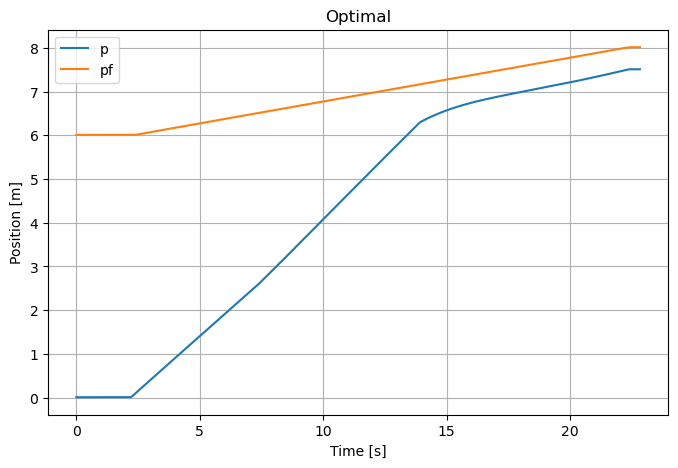

In [17]:
# ============================================================
# Plot car positions of optimal control 
# ============================================================
t_1_opt = (
    (df_odom_1_optimal["time_ns"] - df_odom_1_optimal["time_ns"].iloc[0]) * 1e-9
).to_numpy()

t_2_opt = (
    (df_odom_2_optimal["time_ns"] - df_odom_2_optimal["time_ns"].iloc[0]) * 1e-9
).to_numpy()

p_1_opt = df_odom_1_optimal["position_x"].to_numpy()
p_2_opt = df_odom_2_optimal["position_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_1_opt, p_1_opt, label="p")
plt.plot(t_2_opt, p_2_opt, label="pf")

plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Optimal")
plt.legend()
plt.grid(True)
plt.show()

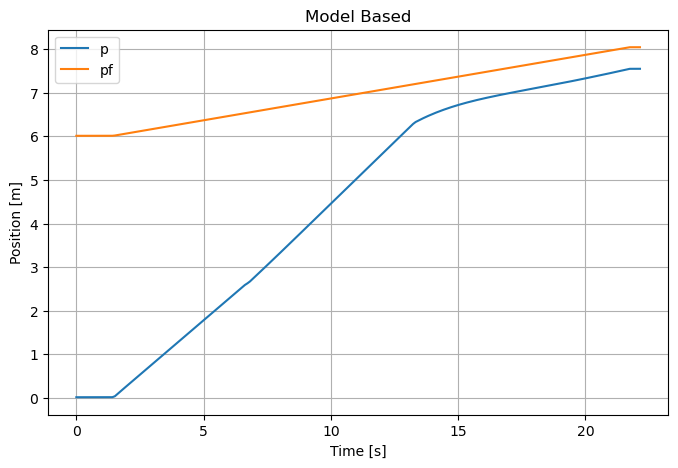

In [18]:
# ============================================================
# Plot car positions of modelbased control
# ============================================================
t_1_mb = (
    (df_odom_1_mb["time_ns"] - df_odom_1_mb["time_ns"].iloc[0]) * 1e-9
).to_numpy()

t_2_mb = (
    (df_odom_2_mb["time_ns"] - df_odom_2_mb["time_ns"].iloc[0]) * 1e-9
).to_numpy()

p_1_mb = df_odom_1_mb["position_x"].to_numpy()
p_2_mb = df_odom_2_mb["position_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_1_mb, p_1_mb, label="p")
plt.plot(t_2_mb, p_2_mb, label="pf")

plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Model Based")
plt.legend()
plt.grid(True)
plt.show()

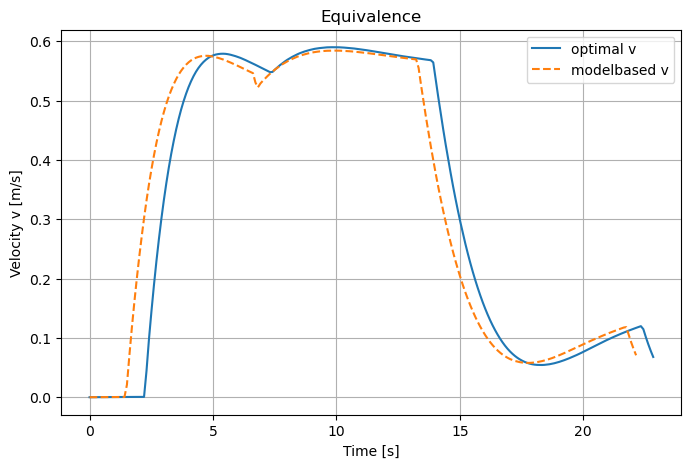

In [19]:
# ============================================================
# Plot state velocity from both bags on the same plot
# ============================================================
t_opt = (
    (df_odom_1_optimal["time_ns"] - df_odom_1_optimal["time_ns"].iloc[0]) * 1e-9
).to_numpy()

t_mb = (
    (df_odom_1_mb["time_ns"] - df_odom_1_mb["time_ns"].iloc[0]) * 1e-9
).to_numpy()

v_opt = df_odom_1_optimal["linear_x"].to_numpy()
v_mb = df_odom_1_mb["linear_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_opt, v_opt, label="optimal v")
plt.plot(t_mb, v_mb, label="modelbased v", linestyle='dashed')

plt.xlabel("Time [s]")
plt.ylabel("Velocity v [m/s]")
plt.title("Equivalence")
plt.legend()
plt.grid(True)
plt.show()

# Processed Data

Keep data only for $t \in [0, T]$, i.e. start and end of PMP control

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def trim_bag_to_gap_window(dfs, gap_threshold=4.0, window_length=15.0):
    """
    For one bag (represented by dfs), find:
        t_start = first time where x_limo2 - x_limo1 <= gap_threshold
        t_end   = t_start + window_length

    Then trim every dataframe in dfs to [t_start, t_end] using the bag's
    common relative time axis.

    Returns
    -------
    trimmed_dfs : dict
        Same keys as dfs, but each dataframe only contains rows in [t_start, t_end]
        and includes a new column 'time_s'.
    t_start : float
        Start time in seconds (relative to bag start).
    t_end : float
        End time in seconds.
    """

    df_odom_1 = dfs["/limo_1/odometry/filtered"].copy()
    df_odom_2 = dfs["/limo_2/odometry/filtered"].copy()

    if df_odom_1.empty or df_odom_2.empty:
        raise RuntimeError("One of the odometry dataframes is empty.")

    # Common bag start time
    t0 = min(df_odom_1["time_ns"].iloc[0], df_odom_2["time_ns"].iloc[0])

    # Relative times in seconds
    t1 = ((df_odom_1["time_ns"] - t0) * 1e-9).to_numpy()
    t2 = ((df_odom_2["time_ns"] - t0) * 1e-9).to_numpy()

    x1 = df_odom_1["position_x"].to_numpy()
    x2 = df_odom_2["position_x"].to_numpy()

    # Overlapping time interval only
    t_min = max(t1.min(), t2.min())
    t_max = min(t1.max(), t2.max())

    if t_max <= t_min:
        raise RuntimeError("The two odometry topics do not have overlapping time ranges.")

    # Common time grid from the union of timestamps, restricted to overlap
    t_common = np.union1d(t1, t2)
    t_common = t_common[(t_common >= t_min) & (t_common <= t_max)]

    if t_common.size == 0:
        raise RuntimeError("No common time grid could be constructed.")

    # Interpolate x positions onto common grid
    x1_common = np.interp(t_common, t1, x1)
    x2_common = np.interp(t_common, t2, x2)

    gap = x2_common - x1_common

    # First time gap <= threshold
    idx = np.where(gap <= gap_threshold)[0]
    if idx.size == 0:
        raise RuntimeError(
            f"Condition x_limo2 - x_limo1 <= {gap_threshold} was never met in this bag."
        )

    t_start = t_common[idx[0]]
    t_end = t_start + window_length

    # Trim every dataframe in dfs to [t_start, t_end]
    trimmed_dfs = {}

    for topic_name, df in dfs.items():
        df_trim = df.copy()

        if df_trim.empty:
            df_trim["time_s"] = pd.Series(dtype=float)
            trimmed_dfs[topic_name] = df_trim
            continue

        df_trim["time_s"] = (df_trim["time_ns"] - t0) * 1e-9
        df_trim = df_trim[(df_trim["time_s"] >= t_start) & (df_trim["time_s"] <= t_end)].copy()

        trimmed_dfs[topic_name] = df_trim.reset_index(drop=True)

    return trimmed_dfs, t_start, t_end

In [21]:
trimmed_dfs_optimal, t_start_opt, t_end_opt = trim_bag_to_gap_window(
    dfs_optimal,
    gap_threshold=4.0,
    window_length=15.0
)

trimmed_dfs_modelbased, t_start_mb, t_end_mb = trim_bag_to_gap_window(
    dfs_modelbased,
    gap_threshold=4.0,
    window_length=15.0
)

print(f"optimal:    t_start = {t_start_opt:.3f} s, t_end = {t_end_opt:.3f} s")
print(f"modelbased: t_start = {t_start_mb:.3f} s, t_end = {t_end_mb:.3f} s")

optimal:    t_start = 7.214 s, t_end = 22.214 s
modelbased: t_start = 6.521 s, t_end = 21.521 s


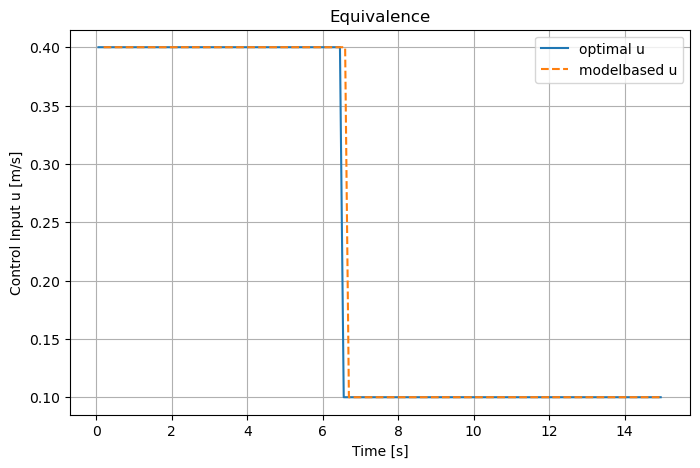

In [22]:
df_pmp_vel_1_optimal_trim = trimmed_dfs_optimal["/limo_1/pmp_vel"]
df_pmp_vel_1_modelbased_trim = trimmed_dfs_modelbased["/limo_1/pmp_vel"]

t_opt = (df_pmp_vel_1_optimal_trim["time_s"] - t_start_opt).to_numpy()
t_mb = (df_pmp_vel_1_modelbased_trim["time_s"] - t_start_mb).to_numpy()

v_opt = df_pmp_vel_1_optimal_trim["linear_x"].to_numpy()
v_mb = df_pmp_vel_1_modelbased_trim["linear_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_opt, v_opt, label="optimal u")
plt.plot(t_mb, v_mb, label="modelbased u", linestyle='dashed')

plt.xlabel("Time [s]")
plt.ylabel("Control Input u [m/s]")
plt.title("Equivalence")
plt.legend()
plt.grid(True)
plt.show()

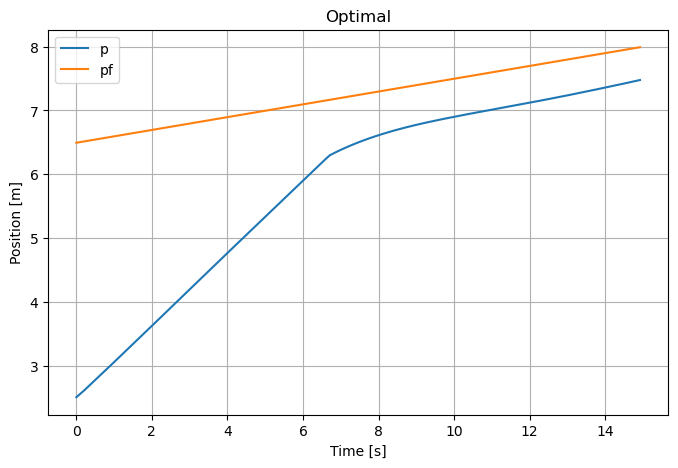

In [23]:
df_odom_1_optimal_trim = trimmed_dfs_optimal["/limo_1/odometry/filtered"]
df_odom_2_optimal_trim = trimmed_dfs_optimal["/limo_2/odometry/filtered"]

t_1_opt = (
    (df_odom_1_optimal_trim["time_ns"] - df_odom_1_optimal_trim["time_ns"].iloc[0]) * 1e-9
).to_numpy()

t_2_opt = (
    (df_odom_2_optimal_trim["time_ns"] - df_odom_2_optimal_trim["time_ns"].iloc[0]) * 1e-9
).to_numpy()

p_1_opt = df_odom_1_optimal_trim["position_x"].to_numpy()
p_2_opt = df_odom_2_optimal_trim["position_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_1_opt, p_1_opt, label="p")
plt.plot(t_2_opt, p_2_opt, label="pf")

plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Optimal")
plt.legend()
plt.grid(True)
plt.show()

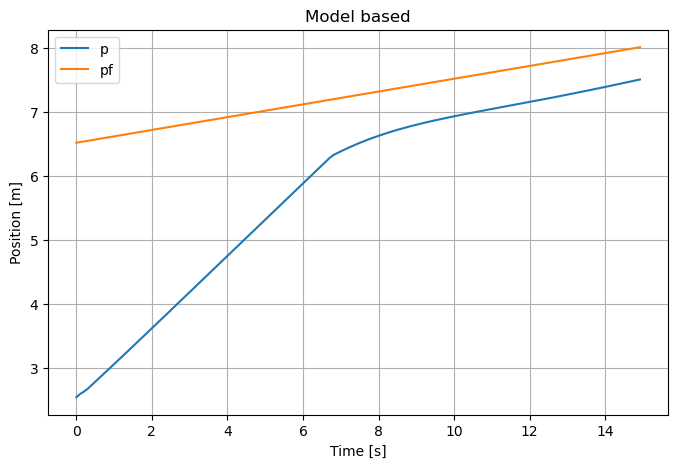

In [24]:
df_odom_1_modelbased_trim = trimmed_dfs_modelbased["/limo_1/odometry/filtered"]
df_odom_2_modelbased_trim = trimmed_dfs_modelbased["/limo_2/odometry/filtered"]

t_1_modelbased = (
    (df_odom_1_modelbased_trim["time_ns"] - df_odom_1_modelbased_trim["time_ns"].iloc[0]) * 1e-9
).to_numpy()

t_2_modelbased = (
    (df_odom_2_modelbased_trim["time_ns"] - df_odom_2_modelbased_trim["time_ns"].iloc[0]) * 1e-9
).to_numpy()

p_1_modelbased = df_odom_1_modelbased_trim["position_x"].to_numpy()
p_2_modelbased = df_odom_2_modelbased_trim["position_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_1_opt, p_1_modelbased, label="p")
plt.plot(t_2_opt, p_2_modelbased, label="pf")

plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Model based")
plt.legend()
plt.grid(True)
plt.show()

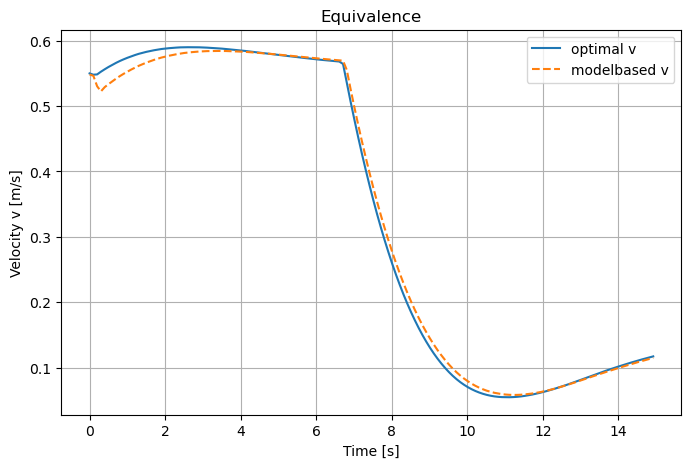

In [25]:
# ============================================================
# Plot state velocity from both bags on the same plot
# ============================================================
t_opt = (
    (df_odom_1_optimal_trim["time_ns"] - df_odom_1_optimal_trim["time_ns"].iloc[0]) * 1e-9
).to_numpy()

t_mb = (
    (df_odom_1_modelbased_trim["time_ns"] - df_odom_1_modelbased_trim["time_ns"].iloc[0]) * 1e-9
).to_numpy()

v_opt = df_odom_1_optimal_trim["linear_x"].to_numpy()
v_mb = df_odom_1_modelbased_trim["linear_x"].to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(t_opt, v_opt, label="optimal v")
plt.plot(t_mb, v_mb, label="modelbased v", linestyle='dashed')

plt.xlabel("Time [s]")
plt.ylabel("Velocity v [m/s]")
plt.title("Equivalence")
plt.legend()
plt.grid(True)
plt.show()

# Compute Cost

In [26]:
import numpy as np

# ============================================================
# Cost parameters
# ============================================================
dt = 0.1
q = 1.0
r = 0.5
v_ref = 0.6
h = 1.0

k = 1.4
tau = 0.1


def compute_trajectory_cost_with_dynamics(
    trimmed_dfs,
    dt=0.1,
    q=1.0,
    r=0.5,
    v_ref=0.6,
    h=1.0,
    k=1.4,
    tau=0.1
):
    """
    Compute
        J = dt * sum_t [ q (v(t)-v_ref)^2 + r a(t)^2 ] + h (v(t_end)-v_ref)^2

    where
        a(t) = (k*u(t) - v(t))/tau

    using:
      - u(t): /limo_1/pmp_vel -> linear_x
      - v(t): /limo_1/odometry/filtered -> linear_x

    Parameters
    ----------
    trimmed_dfs : dict
        Dictionary of trimmed pandas DataFrames. Must contain:
          - '/limo_1/pmp_vel' with columns 'time_s', 'linear_x'
          - '/limo_1/odometry/filtered' with columns 'time_s', 'linear_x'

    Returns
    -------
    results : dict
        Dictionary with interpolated signals and cost components.
    """

    df_u = trimmed_dfs["/limo_1/pmp_vel"].copy()
    df_v = trimmed_dfs["/limo_1/odometry/filtered"].copy()

    if df_u.empty:
        raise RuntimeError("Trimmed dataframe for /limo_1/pmp_vel is empty.")
    if df_v.empty:
        raise RuntimeError("Trimmed dataframe for /limo_1/odometry/filtered is empty.")

    # Extract time and signals
    t_u = df_u["time_s"].to_numpy(dtype=float)
    u = df_u["linear_x"].to_numpy(dtype=float)

    t_v = df_v["time_s"].to_numpy(dtype=float)
    v = df_v["linear_x"].to_numpy(dtype=float)

    # Sort by time
    idx_u = np.argsort(t_u)
    t_u = t_u[idx_u]
    u = u[idx_u]

    idx_v = np.argsort(t_v)
    t_v = t_v[idx_v]
    v = v[idx_v]

    # Remove duplicate timestamps
    t_u, unique_idx_u = np.unique(t_u, return_index=True)
    u = u[unique_idx_u]

    t_v, unique_idx_v = np.unique(t_v, return_index=True)
    v = v[unique_idx_v]

    if len(t_u) < 2:
        raise RuntimeError("Not enough /limo_1/pmp_vel samples to compute cost.")
    if len(t_v) < 2:
        raise RuntimeError("Not enough /limo_1/odometry/filtered samples to compute cost.")

    # Use overlapping interval only
    t0 = max(t_u[0], t_v[0])
    tf = min(t_u[-1], t_v[-1])

    if tf <= t0:
        raise RuntimeError("No overlapping time interval between u(t) and v(t).")

    # Uniform grid with spacing dt
    t_grid = np.arange(t0, tf + 0.5 * dt, dt)
    t_grid = t_grid[t_grid <= tf + 1e-12]

    if len(t_grid) < 1:
        raise RuntimeError("Interpolated time grid is empty.")

    # Interpolate both signals to the same grid
    u_grid = np.interp(t_grid, t_u, u)
    v_grid = np.interp(t_grid, t_v, v)

    # Dynamics-based acceleration
    a_grid = (k * u_grid - v_grid) / tau

    # Cost terms
    tracking_term = q * (v_grid - v_ref) ** 2
    control_term = r * (a_grid ** 2)

    running_cost = dt * np.sum(tracking_term + control_term)
    terminal_cost = h * (v_grid[-1] - v_ref) ** 2
    total_cost = running_cost + terminal_cost

    return {
        "t_grid": t_grid,
        "u_grid": u_grid,
        "v_grid": v_grid,
        "a_grid": a_grid,
        "tracking_term": tracking_term,
        "control_term": control_term,
        "running_cost": running_cost,
        "terminal_cost": terminal_cost,
        "total_cost": total_cost,
    }


# ============================================================
# Compute costs for both bags
# ============================================================
cost_optimal = compute_trajectory_cost_with_dynamics(
    trimmed_dfs_optimal,
    dt=dt,
    q=q,
    r=r,
    v_ref=v_ref,
    h=h,
    k=k,
    tau=tau
)

cost_modelbased = compute_trajectory_cost_with_dynamics(
    trimmed_dfs_modelbased,
    dt=dt,
    q=q,
    r=r,
    v_ref=v_ref,
    h=h,
    k=k,
    tau=tau
)

print("Optimal trajectory cost:")
print(f"  running cost  = {cost_optimal['running_cost']:.6f}")
print(f"  terminal cost = {cost_optimal['terminal_cost']:.6f}")
print(f"  total cost    = {cost_optimal['total_cost']:.6f}")

print("\nModel-based trajectory cost:")
print(f"  running cost  = {cost_modelbased['running_cost']:.6f}")
print(f"  terminal cost = {cost_modelbased['terminal_cost']:.6f}")
print(f"  total cost    = {cost_modelbased['total_cost']:.6f}")

print("\n================ COST COMPARISON ================")
print(f"Optimal total cost:     {cost_optimal['total_cost']:.6f}")
print(f"Model-based total cost: {cost_modelbased['total_cost']:.6f}")
print(f"Difference (MB - OPT):  {cost_modelbased['total_cost'] - cost_optimal['total_cost']:.6f}")

Optimal trajectory cost:
  running cost  = 10.019127
  terminal cost = 0.234195
  total cost    = 10.253322

Model-based trajectory cost:
  running cost  = 9.354574
  terminal cost = 0.235961
  total cost    = 9.590535

================ COST COMPARISON ================
Optimal total cost:     10.253322
Model-based total cost: 9.590535
Difference (MB - OPT):  -0.662787


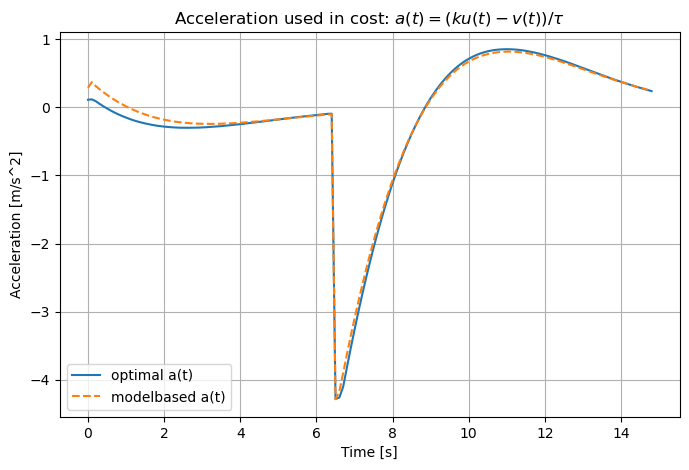

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(cost_optimal["t_grid"] - cost_optimal["t_grid"][0], cost_optimal["a_grid"], label="optimal a(t)")
plt.plot(cost_modelbased["t_grid"] - cost_modelbased["t_grid"][0], cost_modelbased["a_grid"], label="modelbased a(t)", linestyle='dashed')

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s^2]")
plt.title(r"Acceleration used in cost: $a(t) = (k u(t) - v(t))/\tau$")
plt.grid(True)
plt.legend()
plt.show()